In [2]:
# Importations
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score


In [ ]:
first_data_tree = pd.read_csv("/Data_Arbre_Clean.csv")

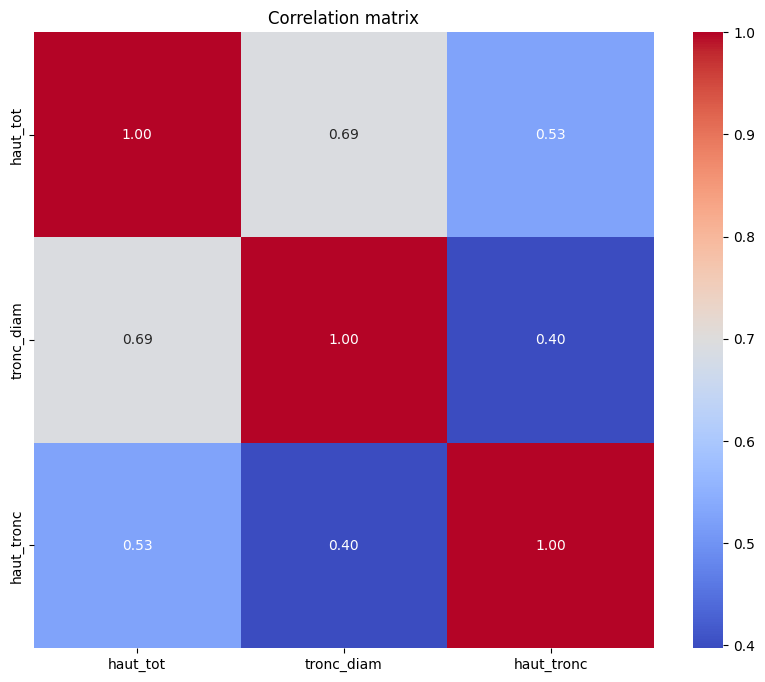

In [42]:
# Selection of the colums with tree dimensions
colonnes_dimensions = ['haut_tot', 'tronc_diam', 'haut_tronc']
df_dims = first_data_tree[colonnes_dimensions]

# Calculation of the correlation matrix
corr_matrix = df_dims.corr()

# Figure in heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(first_data_tree['haut_tot'].dropna(), bins=30, kde=True)
plt.title('Distribution of Total Height (haut_tot)')
plt.xlabel('Total Height')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Take only the interesting colums and remove null values
tree_height=first_data_tree[['haut_tot']].dropna()

# Standard the values
scaler=StandardScaler()
tree_stand=scaler.fit_transform(tree_height)

In [ ]:
from matplotlib import legend
inertia = []
label= []
s_score=[]
c_score=[]
d_score=[]
K_range = range(1, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    label.append(kmeans.fit_predict(tree_stand))
    if k !=1:
      s_score.append(silhouette_score(tree_stand,label[k-1]))
      c_score.append(calinski_harabasz_score(tree_stand,label[k-1]))
      d_score.append(davies_bouldin_score(tree_stand,label[k-1]))
    inertia.append(kmeans.inertia_)

# Figure the inertia
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Total inertia')
plt.title('Elbow Method')
plt.legend()
plt.show()

NameError: name 'KMeans' is not defined

In [ ]:
# Figure the score
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(K_range[1:], s_score, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.subplot(1, 3, 2)
plt.plot(K_range[1:], c_score, 'rx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Score')

plt.subplot(1, 3, 3) 
plt.plot(K_range[1:], d_score, 'gx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Davies-Bouldin Score')
plt.title('Davies-Bouldin Score')

plt.tight_layout() 
plt.show()

In [ ]:
# Add the cluster of each tree in the data
tree_height['cluster_2']=label[0]
tree_height['cluster_3']=label[1]
# Create a csv with the new data
final_data_tree = first_data_tree.join(tree_height[['cluster_2', 'cluster_3']])
final_data_tree.to_csv('arbres_complet_avec_clusters.csv', index=False)